# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
%pip install datasets pandas matplotlib seaborn textblob emoji wordcloud

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from textblob import TextBlob
import emoji
import re
from wordcloud import WordCloud

c:\Users\zakis\miniconda3\envs\mlflow_learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
print("Loading dataset from Hugging Face...")
# The dataset has a 'train' split with 'label' and 'text' columns
dataset = load_dataset("ksang/TwitchStreams", split="train")
df = dataset.to_pandas()

print(f"Dataset loaded. Shape: {df.shape}")
display(df.head(25))

# Export to a local CSV file
df.to_csv("../twitch_streams_raw_data.csv", index=False)
print("Successfully saved as twitch_streams_raw_data.csv!")

Loading dataset from Hugging Face...


Repo card metadata block was not found. Setting CardData to empty.


Dataset loaded. Shape: (3432, 2)


,label,text
0,SAFE,"""💀DRAMA💀END TIMES💀SEASON FINALE💀EXTENDED CUT💀D..."
1,SAFE,"""Screen grey LMAO"""
2,SAFE,"""THE RETURN TO MONKEY ISLAND! - !BasementTour ..."
3,SAFE,"""CUSTOMS BLAST BALLS with CAS! CODE: XXJLR"""
4,MATURE,"""fortnite (dota soloq) !nord"""
5,SAFE,"""(DROPS) ICON SKIN GAMEPLAY - Season 4 Update ..."
6,SAFE,"""🕵️ SUBATHON UNCAPPED 🕵️ OR UNTIL MY VACATION ..."
7,SAFE,"""yo, couldn't sleep"""
8,SAFE,"""NEW FORTNITE SEASON POGGERS DRAMA FREE XD"""
9,SAFE,"""💎 200% + $50 Deposit Bonus! 💎 Use Referral Li..."


Successfully saved as twitch_streams_raw_data.csv!


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Calculate basic length metrics
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Extract and count emojis (highly indicative of sentiment in Twitch chats)
def extract_emojis(text):
    return ''.join(c for c in text if c in emoji.EMOJI_DATA)

df['emojis'] = df['text'].apply(extract_emojis)
df['emoji_count'] = df['emojis'].apply(len)

# Flag all-caps text (often represents excitement, anger, or spam)
def is_all_caps(text):
    # Filter out very short texts and check if uppercase letters dominate
    alpha_text = re.sub(r'[^a-zA-Z]', '', text)
    if len(alpha_text) > 3 and alpha_text.isupper():
        return 1
    return 0

df['is_all_caps'] = df['text'].apply(is_all_caps)

In [6]:
df['polarity'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['subjectivity'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# Categorize sentiment for easier grouping
df['sentiment_category'] = pd.cut(
    df['polarity'], 
    bins=[-1, 0, 1], 
    labels=['SAFE', 'MATURE']
)

C:\Users\zakis\AppData\Local\Temp\ipykernel_14104\3806397092.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis', ax=ax_count)
C:\Users\zakis\AppData\Local\Temp\ipykernel_14104\3806397092.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='polarity', palette='coolwarm', ax=ax_box)



Generating Word Clouds into the subplot layout...


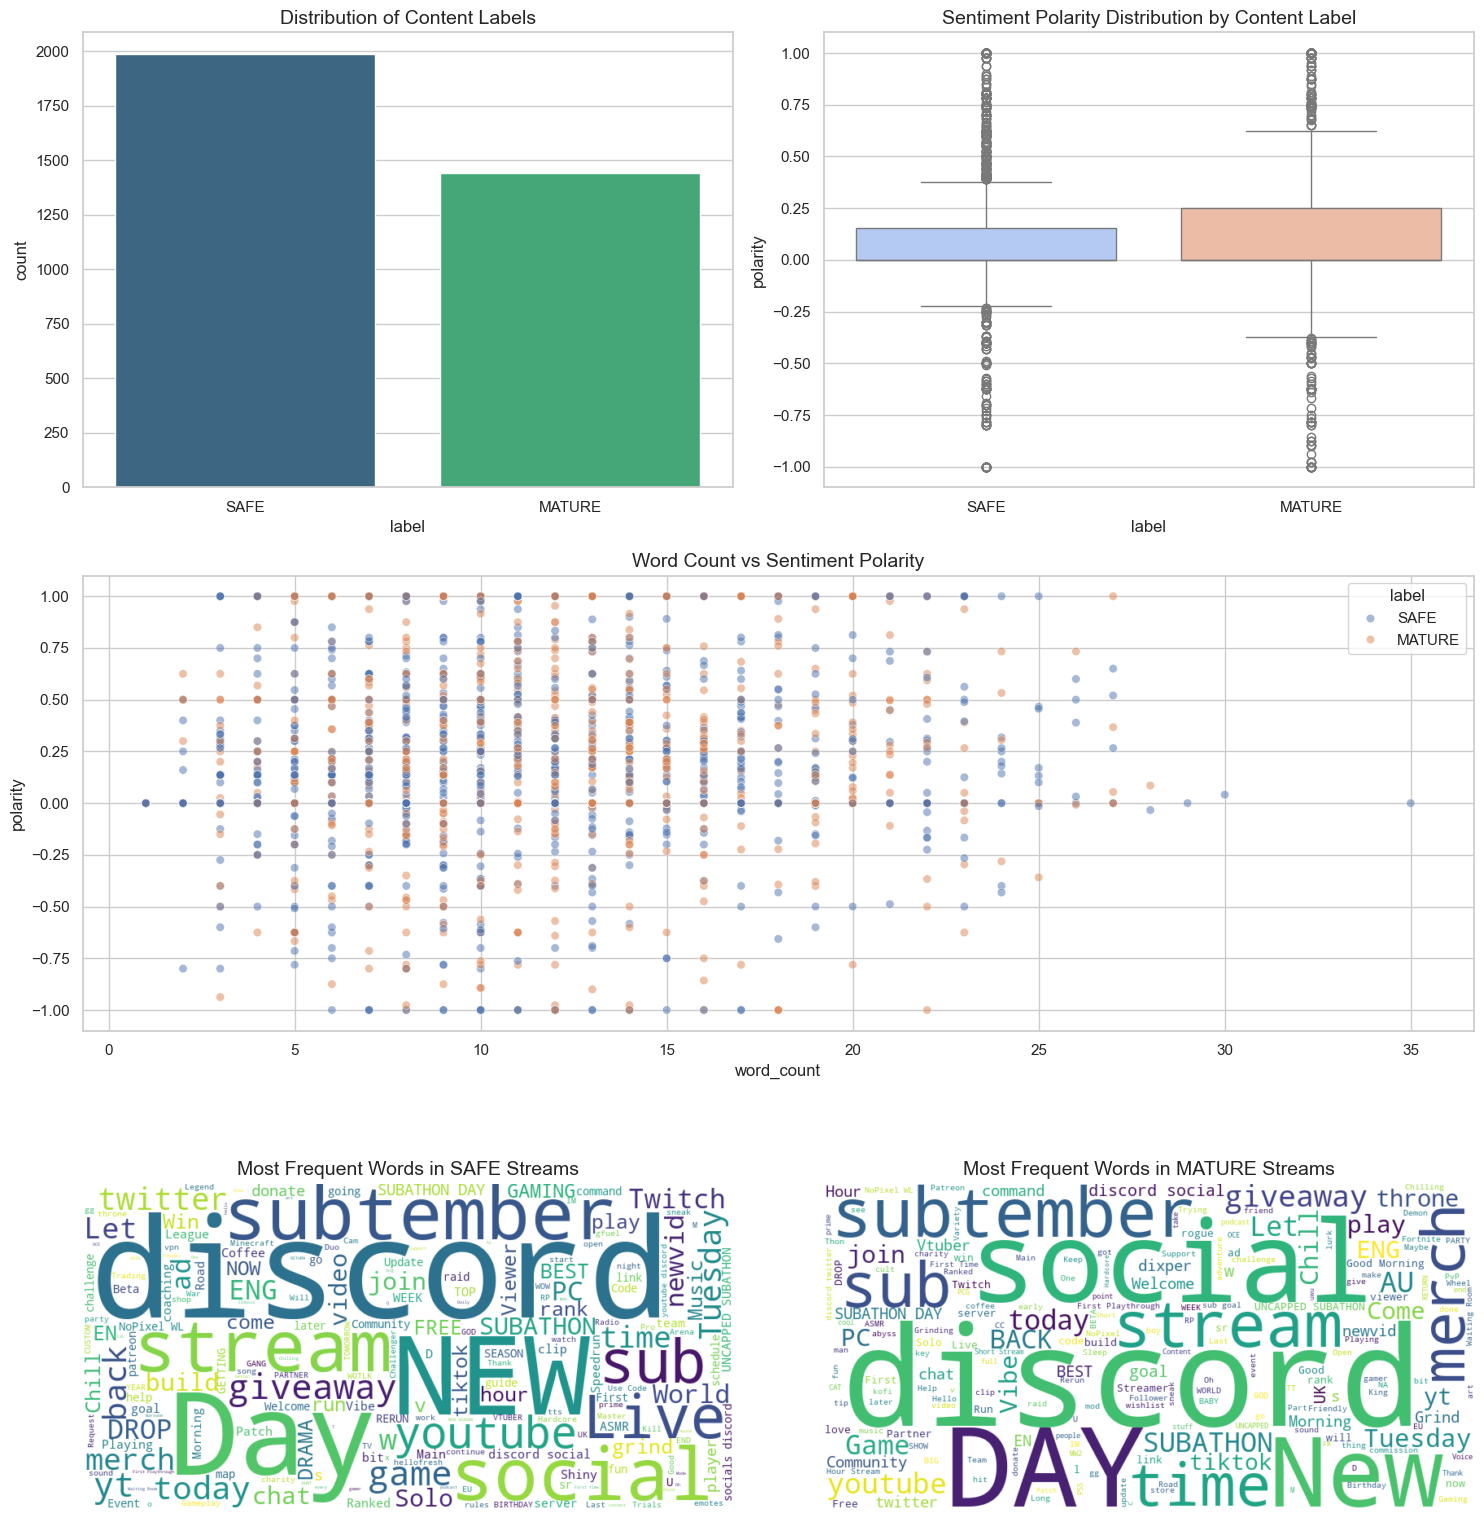

In [7]:
# Set global seaborn theme style
sns.set_theme(style="whitegrid")

# 1. Initialize a single large figure canvas
# Adjust figsize as needed to make sure everything fits without crowding
fig = plt.figure(figsize=(15, 16))

# 2. Define a grid layout (3 rows, 2 columns) using subplot2grid
ax_count = plt.subplot2grid((3, 2), (0, 0))
ax_box = plt.subplot2grid((3, 2), (0, 1))
ax_scatter = plt.subplot2grid((3, 2), (1, 0), colspan=2) # Spans across both columns
ax_wc_safe = plt.subplot2grid((3, 2), (2, 0))
ax_wc_mature = plt.subplot2grid((3, 2), (2, 1))

# --- A. Class Distribution (SAFE vs MATURE) ---
sns.countplot(data=df, x='label', palette='viridis', ax=ax_count)
ax_count.set_title('Distribution of Content Labels', fontsize=14)

# --- B. Sentiment Polarity by Content Label ---
sns.boxplot(data=df, x='label', y='polarity', palette='coolwarm', ax=ax_box)
ax_box.set_title('Sentiment Polarity Distribution by Content Label', fontsize=14)

# --- C. Correlation between Word Count and Sentiment ---
sns.scatterplot(data=df, x='word_count', y='polarity', alpha=0.5, hue='label', ax=ax_scatter)
ax_scatter.set_title('Word Count vs Sentiment Polarity', fontsize=14)


# --- D. Function to generate wordcloud onto a specific axis ---
def add_wordcloud_to_axis(ax, content_label, title):
    # NOTE: Using df['label'] here to match 'SAFE' / 'MATURE'. 
    # Change to df['sentiment_category'] if you decide to pass 'Positive'/'Negative' instead.
    text_data = " ".join(df[df['label'] == content_label]['text'].dropna().tolist())
    
    # Clean out basic symbols for the word cloud
    text_data = re.sub(r'http\S+|www\S+|https\S+', '', text_data, flags=re.MULTILINE)
    
    # Check if there is text available to prevent WordCloud from throwing an error
    if text_data.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(title, fontsize=14)
    else:
        ax.text(0.5, 0.5, f"No text data found for {content_label}", ha='center', va='center', fontsize=12)
        
    ax.axis("off") # Crucial: Hide the grid lines/axes for word clouds

# Generate Word Clouds directly into their designated subplot axes
print("\nGenerating Word Clouds into the subplot layout...")
add_wordcloud_to_axis(ax_wc_safe, 'SAFE', 'Most Frequent Words in SAFE Streams')
add_wordcloud_to_axis(ax_wc_mature, 'MATURE', 'Most Frequent Words in MATURE Streams')

# 3. Automatically adjust spacing so titles and axes don't overlap
plt.tight_layout()

# 4. Display the single combined dashboard
plt.show()

In [8]:
print("\n--- Summary Statistics ---")
display(df.groupby('label')[['char_count', 'word_count', 'emoji_count', 'polarity']].mean())

print("\n--- Top 5 Most Negative Streams ---")
display(df.sort_values(by='polarity').head(5)[['text', 'polarity', 'label']])

print("\n--- Top 5 Most Positive Streams ---")
display(df.sort_values(by='polarity', ascending=False).head(5)[['text', 'polarity', 'label']])


--- Summary Statistics ---


,char_count,word_count,emoji_count,polarity
label,,,,
MATURE,61.653740,10.175900,0.488227,0.123287
SAFE,57.089034,9.512072,0.503018,0.097874



--- Top 5 Most Negative Streams ---


,text,polarity,label
3154,"""[ENG] What's your worst nightmare!? Let's get...",-1.0,SAFE
622,"""Lets The Crazy Release Schedules Begin! Morni...",-1.0,SAFE
606,"""SEA offlane rank games!! ˶ᵔ ᵕ ᵔ˶ | !discord ...",-1.0,SAFE
494,"""ONE STEP BEFORE #1 ON LADDER || #BEEFORWOLOLO...",-1.0,SAFE
653,"""ITSMY HOME | XTEAM WATCHPARTY !giveaway !newv...",-1.0,SAFE



--- Top 5 Most Positive Streams ---


,text,polarity,label
3414,"""Best HSP eating Kazuya""",1.0,SAFE
22,"""BEST 8KD WARZONE PLAYER | !newvid !socials !...",1.0,SAFE
20,"""XQC PARTY QUEUE REALLY? YES!!!!!! !birthday !...",1.0,SAFE
3052,"""Leyline Overflow :D - AR 60 Day 450+ - !art !...",1.0,SAFE
3317,"""Welcome To DEVILS BAR | Marbles with viewers ...",1.0,MATURE


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Copy data agar dataframe asli tetap aman
df_prep = df.copy()

print("=== PREPROCESSING CHECKLIST ===")
print(f"Ukuran awal data: {df_prep.shape}")

# Step 1 - Validasi kolom utama (text dan label)
text_col_candidates = ["text", "content", "caption", "tweet", "comment"]
label_col_candidates = ["label", "target", "class", "sentiment"]

text_col = next((c for c in text_col_candidates if c in df_prep.columns), None)
label_col = next((c for c in label_col_candidates if c in df_prep.columns), None)

if text_col is None:
    raise ValueError("Kolom teks tidak ditemukan. Pastikan ada kolom seperti: text/content/caption/tweet/comment")

print(f"Kolom teks terdeteksi: {text_col}")
print(f"Kolom label terdeteksi: {label_col if label_col else 'Tidak ada (opsional)'}")

# Step 2 - Tangani missing values
missing_before = df_prep.isna().sum().sum()
print(f"\nTotal missing values sebelum cleaning: {missing_before}")

# Drop baris yang teksnya kosong
df_prep = df_prep.dropna(subset=[text_col]).copy()

# Jika supervised learning, label kosong dibuang
if label_col:
    df_prep = df_prep.dropna(subset=[label_col]).copy()

# Isi missing pada kolom numerik dengan median
numeric_cols = df_prep.select_dtypes(include=[np.number]).columns
for c in numeric_cols:
    if df_prep[c].isna().sum() > 0:
        df_prep[c] = df_prep[c].fillna(df_prep[c].median())

# Isi missing pada kolom non-numerik dengan modus (fallback: 'unknown')
object_cols = df_prep.select_dtypes(exclude=[np.number]).columns
for c in object_cols:
    if df_prep[c].isna().sum() > 0:
        mode_val = df_prep[c].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else "unknown"
        df_prep[c] = df_prep[c].fillna(fill_val)

missing_after = df_prep.isna().sum().sum()
print(f"Total missing values sesudah cleaning: {missing_after}")

# Step 3 - Hapus duplikasi
dup_before = df_prep.duplicated().sum()
text_dup_before = df_prep.duplicated(subset=[text_col]).sum()

df_prep = df_prep.drop_duplicates().copy()
df_prep = df_prep.drop_duplicates(subset=[text_col]).copy()

print(f"\nDuplikat full-row yang dihapus: {dup_before}")
print(f"Duplikat teks yang dihapus: {text_dup_before}")

# Step 4 - Cleaning teks
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # hapus URL
    text = re.sub(r"@\w+", " ", text)                    # hapus mention
    text = re.sub(r"#(\w+)", r"\1", text)               # simpan kata hashtag, hapus '#'
    text = re.sub(r"[^a-z\s]", " ", text)               # sisakan huruf + spasi
    text = re.sub(r"\s+", " ", text).strip()            # rapikan spasi

    # stopword removal sederhana (English)
    tokens = [t for t in text.split() if t not in ENGLISH_STOP_WORDS and len(t) > 1]
    return " ".join(tokens)


df_prep["clean_text"] = df_prep[text_col].apply(clean_text)

# Step 5 - Hapus baris dengan clean_text kosong
df_prep = df_prep[df_prep["clean_text"].str.len() > 0].copy()

# Step 6 - Feature dasar dari clean_text
df_prep["clean_char_count"] = df_prep["clean_text"].str.len()
df_prep["clean_word_count"] = df_prep["clean_text"].str.split().str.len()

# Step 7 - (Opsional) Siapkan data akhir untuk modeling
if label_col:
    model_df = df_prep[["clean_text", label_col]].copy()
else:
    model_df = df_prep[["clean_text"]].copy()

print("\n=== RINGKASAN HASIL PREPROCESSING ===")
print(f"Ukuran akhir data: {df_prep.shape}")
print("Contoh data siap model:")
display(model_df.head())

print("\nContoh kolom tambahan:")
display(df_prep[[text_col, "clean_text", "clean_char_count", "clean_word_count"]].head())

=== PREPROCESSING CHECKLIST ===
Ukuran awal data: (3432, 10)
Kolom teks terdeteksi: text
Kolom label terdeteksi: label

Total missing values sebelum cleaning: 33
Total missing values sesudah cleaning: 0

Duplikat full-row yang dihapus: 58
Duplikat teks yang dihapus: 59

=== RINGKASAN HASIL PREPROCESSING ===
Ukuran akhir data: (3349, 13)
Contoh data siap model:


,clean_text,label
0,drama end times season finale extended cut dir...,SAFE
1,screen grey lmao,SAFE
2,return monkey island basementtour mobileapp pc,SAFE
3,customs blast balls cas code xxjlr,SAFE
4,fortnite dota soloq nord,MATURE



Contoh kolom tambahan:


,text,clean_text,clean_char_count,clean_word_count
0,"""💀DRAMA💀END TIMES💀SEASON FINALE💀EXTENDED CUT💀D...",drama end times season finale extended cut dir...,124,19
1,"""Screen grey LMAO""",screen grey lmao,16,3
2,"""THE RETURN TO MONKEY ISLAND! - !BasementTour ...",return monkey island basementtour mobileapp pc,46,6
3,"""CUSTOMS BLAST BALLS with CAS! CODE: XXJLR""",customs blast balls cas code xxjlr,34,6
4,"""fortnite (dota soloq) !nord""",fortnite dota soloq nord,24,4


In [10]:
display(df_prep)

,label,text,char_count,word_count,emojis,emoji_count,is_all_caps,polarity,subjectivity,sentiment_category,clean_text,clean_char_count,clean_word_count
0,SAFE,"""💀DRAMA💀END TIMES💀SEASON FINALE💀EXTENDED CUT💀D...",128,9,💀💀💀💀💀💀💀💀💀💀💀💀,12,1,0.000000,0.000000,SAFE,drama end times season finale extended cut dir...,124,19
1,SAFE,"""Screen grey LMAO""",18,3,,0,0,0.275000,0.550000,MATURE,screen grey lmao,16,3
2,SAFE,"""THE RETURN TO MONKEY ISLAND! - !BasementTour ...",65,11,,0,0,-0.122070,0.000000,SAFE,return monkey island basementtour mobileapp pc,46,6
3,SAFE,"""CUSTOMS BLAST BALLS with CAS! CODE: XXJLR""",43,7,,0,0,0.000000,0.000000,SAFE,customs blast balls cas code xxjlr,34,6
4,MATURE,"""fortnite (dota soloq) !nord""",29,4,,0,0,0.000000,0.000000,SAFE,fortnite dota soloq nord,24,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3426,SAFE,"""Final Fantasy Marathon: FF8!""",30,4,,0,0,0.000000,1.000000,SAFE,final fantasy marathon ff,25,4
3428,SAFE,"""Whatever excites you, go do it!｜Hit the switc...",95,17,,0,0,0.000000,0.000000,SAFE,excites hit switch watch bounce like scott sto...,58,10
3429,SAFE,"""Our animals love to raid and be raided... <3 ...",63,12,,0,0,0.833333,0.600000,MATURE,animals love raid raided joy clan lurk,38,7
3430,SAFE,"""🖋️🎨 Inkmo has been inked! First Tattoo - reve...",52,10,🖋🎨👀🐝,4,0,0.250000,0.333333,MATURE,inkmo inked tattoo reveal,25,4


In [11]:
display(df_prep[["label", "clean_text"]])

,label,clean_text
0,SAFE,drama end times season finale extended cut dir...
1,SAFE,screen grey lmao
2,SAFE,return monkey island basementtour mobileapp pc
3,SAFE,customs blast balls cas code xxjlr
4,MATURE,fortnite dota soloq nord
...,...,...
3426,SAFE,final fantasy marathon ff
3428,SAFE,excites hit switch watch bounce like scott sto...
3429,SAFE,animals love raid raided joy clan lurk
3430,SAFE,inkmo inked tattoo reveal


In [12]:
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split

# Ambil data akhir hasil preprocessing
if "model_df" not in globals():
    raise ValueError("model_df belum tersedia. Jalankan sel preprocessing terlebih dahulu.")

# Tentukan folder output dan replace jika sudah ada
output_dir = Path(r".\preprocessed data")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Train-test split
stratify_target = model_df[label_col] if "label_col" in globals() and label_col in model_df.columns else None
train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_target
)

# Reset index agar rapi saat disimpan
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Simpan ke CSV
train_path = output_dir / "train.csv"
test_path = output_dir / "test.csv"
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Train-test split berhasil dibuat dan disimpan.")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train file: {train_path}")
print(f"Test file: {test_path}")

display(train_df.head())
display(test_df.head())

Train-test split berhasil dibuat dan disimpan.
Train shape: (2679, 2)
Test shape: (670, 2)
Train file: preprocessed data\train.csv
Test file: preprocessed data\test.csv


,clean_text,label
0,damn september drama,MATURE
1,subtember saturday comiccon ticket grabs sub n...,MATURE
2,drop bracelet kakul commands,MATURE
3,nextmaker myteam unlimited grind nba twitter,SAFE
4,hell hardcore druid speedrun druidwr,MATURE


,clean_text,label
0,eu rdm solo heaven high gnb die,MATURE
1,best sniper new fortnite season,SAFE
2,tips tricks win new season use code upshall it...,SAFE
3,construction simulator launch stream,SAFE
4,best asmr come tingle uwu rr,MATURE
